# Aletheia — Multi-source Evidence Relevance

A standalone, executable **deep-learning experiment** with public data collection, leakage checks, training, held-out evaluation, loss graphs and project-compatible export. No repository URL, secret or GPU is required. Select **Runtime → Run all**. CPU is intentional for these compact NumPy networks; this does not fine-tune the chat language model.

**Task:** Learn query–passage relevance from SciQ and SQuAD, using a 516 → 96 → 32 → 2 network.

The feature representation uses normalized hashed words, pair interactions and overlap features. It loses word order. Treat performance as experimental; a high retrieval score does not prove truth.


In [1]:
import importlib.util, os, subprocess, sys
from pathlib import Path
if importlib.util.find_spec("numpy") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy>=2.0,<3"])
ROOT = Path.cwd() / "aletheia-colab" / "backend"
ROOT.mkdir(parents=True, exist_ok=True)


In [2]:
embedded_files = {'scripts/prepare_research_data.py': '#!/usr/bin/env python3\n"""Download attributed public datasets and build document-disjoint research tasks."""\nimport argparse\nfrom collections import Counter, defaultdict\nfrom datetime import datetime, timezone\nimport hashlib\nimport io\nimport json\nfrom pathlib import Path\nimport tarfile\nimport time\nimport urllib.request\nimport zipfile\n\nROOT = Path(__file__).resolve().parents[1]\nSOURCES = {\n    \'sciq\': (\'https://s3-us-west-2.amazonaws.com/ai2-website/data/SciQ.zip\', \'CC BY-NC 3.0\', \'https://huggingface.co/datasets/allenai/sciq\'),\n    \'scifact\': (\'https://scifact.s3-us-west-2.amazonaws.com/release/latest/data.tar.gz\', \'Claims: CC BY 4.0; abstracts: ODC-By 1.0\', \'https://github.com/allenai/scifact/blob/master/LICENSE.md\'),\n    \'squad\': (\'https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v1.1.json\', \'CC BY-SA 4.0\', \'https://rajpurkar.github.io/SQuAD-explorer/\'),\n}\n\ndef digest(text):\n    return hashlib.sha256(\' \'.join(text.lower().split()).encode()).hexdigest()\n\ndef download(name, directory):\n    url, license_name, attribution = SOURCES[name]\n    target = directory / name\n    if not target.exists():\n        for attempt in range(3):\n            try:\n                with urllib.request.urlopen(url, timeout=90) as response:\n                    data = response.read(80 * 1024 * 1024 + 1)\n                if len(data) > 80 * 1024 * 1024:\n                    raise ValueError(\'Dataset exceeds download budget\')\n                target.with_suffix(\'.part\').write_bytes(data)\n                target.with_suffix(\'.part\').replace(target)\n                break\n            except Exception:\n                if attempt == 2:\n                    raise\n                time.sleep(2 ** attempt)\n    data = target.read_bytes()\n    return data, {\'url\': url, \'license\': license_name, \'attribution\': attribution,\n                  \'sha256\': hashlib.sha256(data).hexdigest(), \'bytes\': len(data)}\n\ndef split_records(rows):\n    """Connected components keep shared documents AND duplicate queries together."""\n    parents = {}\n    def root(key):\n        parents.setdefault(key, key)\n        while parents[key] != key:\n            parents[key] = parents[parents[key]]\n            key = parents[key]\n        return key\n    for row in rows:\n        a, b = root(\'q:\' + digest(row[\'query\'])), root(\'d:\' + row[\'group\'])\n        parents[max(a, b)] = min(a, b)\n    for row in rows:\n        group = root(\'d:\' + row[\'group\'])\n        bucket = int(digest(group)[:8], 16) % 100\n        row[\'split\'] = \'train\' if bucket < 70 else \'validation\' if bucket < 85 else \'test\'\n    return rows\n\ndef prepare(output, max_qa=6000):\n    raw = output / \'raw\'\n    raw.mkdir(parents=True, exist_ok=True)\n    payloads, manifest = {}, {}\n    for name in SOURCES:\n        payloads[name], manifest[name] = download(name, raw)\n        print(f\'Downloaded {name}: {manifest[name]["bytes"]:,} bytes\', flush=True)\n    previous = output / \'sources.json\'\n    if previous.exists():\n        old = json.loads(previous.read_text())[\'sources\']\n        for name in manifest:\n            if old[name][\'sha256\'] != manifest[name][\'sha256\']:\n                raise ValueError(f\'{name} changed upstream; use a new output directory to review a new snapshot\')\n    qa, stance = [], []\n    with zipfile.ZipFile(io.BytesIO(payloads[\'sciq\'])) as archive:\n        for name in sorted(archive.namelist()):\n            if name.endswith((\'.json\',)) and Path(name).name in {\'train.json\', \'valid.json\', \'test.json\'}:\n                for i, row in enumerate(json.loads(archive.read(name))):\n                    if row.get(\'support\', \'\').strip():\n                        qa.append(dict(id=f\'sciq:{name}:{i}\', source=\'sciq\', query=row[\'question\'], passage=row[\'support\'], answer=row[\'correct_answer\'], group=digest(row[\'support\']), label=1))\n    # Stable hash sampling, not the first articles/questions in file order.\n    squad = []\n    for article in json.loads(payloads[\'squad\'])[\'data\']:\n        for paragraph in article[\'paragraphs\']:\n            for row in paragraph[\'qas\']:\n                squad.append(dict(id=\'squad:\' + row[\'id\'], source=\'squad\', query=row[\'question\'], passage=paragraph[\'context\'], answer=row[\'answers\'][0][\'text\'], group=\'squad:\' + article[\'title\'], label=1))\n    qa = sorted(qa, key=lambda r: digest(r[\'id\']))[:max_qa] + sorted(squad, key=lambda r: digest(r[\'id\']))[:max_qa]\n    with tarfile.open(fileobj=io.BytesIO(payloads[\'scifact\']), mode=\'r:gz\') as archive:\n        # Read named members only; never extract archive paths onto the filesystem.\n        files = {Path(m.name).name: archive.extractfile(m).read().decode() for m in archive.getmembers() if m.isfile() and Path(m.name).name in {\'corpus.jsonl\', \'claims_train.jsonl\', \'claims_dev.jsonl\'}}\n    corpus = {str(row[\'doc_id\']): row for row in map(json.loads, files[\'corpus.jsonl\'].splitlines())}\n    for filename in [\'claims_train.jsonl\', \'claims_dev.jsonl\']:\n        for claim in map(json.loads, files[filename].splitlines()):\n            for doc_id, annotations in claim[\'evidence\'].items():\n                labels = {item[\'label\'] for item in annotations}\n                if len(labels) != 1 or not labels <= {\'SUPPORT\', \'CONTRADICT\'}:\n                    continue\n                stance.append(dict(id=f\'scifact:{claim["id"]}:{doc_id}\', source=\'scifact\', query=claim[\'claim\'], passage=\' \'.join(corpus[doc_id][\'abstract\']), group=digest(\' \'.join(corpus[doc_id][\'abstract\'])), label=int(next(iter(labels)) == \'SUPPORT\')))\n    # Collapse exact pairs before assigning splits.\n    rows = list({(digest(r[\'query\']), digest(r[\'passage\'])): r for r in qa + stance}.values())\n    split_records(rows)\n    relevance = [r for r in rows if r[\'source\'] != \'scifact\']\n    stance = [r for r in rows if r[\'source\'] == \'scifact\']\n    negatives = []\n    for split in [\'train\', \'validation\', \'test\']:\n        pool = [r for r in relevance if r[\'split\'] == split]\n        for index, row in enumerate(pool):\n            choices = [pool[(index + offset) % len(pool)] for offset in range(1, min(33, len(pool)))]\n            qtokens = set(row[\'query\'].lower().split())\n            choices = [c for c in choices if c[\'source\'] == row[\'source\'] and c[\'group\'] != row[\'group\'] and row[\'answer\'].lower() not in c[\'passage\'].lower() and digest(c[\'query\']) != digest(row[\'query\'])]\n            if not choices:\n                continue\n            candidate = max(choices, key=lambda c: len(qtokens & set(c[\'passage\'].lower().split())))\n            negatives.append({**row, \'id\': row[\'id\'] + \':negative\', \'passage\': candidate[\'passage\'], \'group\': candidate[\'group\'], \'label\': 0, \'label_origin\': \'sampled_nonanswer_passage\'})\n    for task, records in [(\'relevance\', relevance + negatives), (\'stance\', stance)]:\n        path = output / f\'{task}.jsonl\'\n        path.write_text(\'\'.join(json.dumps(r) + \'\\n\' for r in records))\n        print(task, dict(Counter((r[\'split\'], r[\'label\']) for r in records)), flush=True)\n    previous.write_text(json.dumps({\'created_at\': datetime.now(timezone.utc).isoformat(), \'sources\': manifest, \'max_qa_per_source\': max_qa, \'split_policy\': \'70/15/15 hash of connected document/query groups; official SciFact train+dev regrouped; no official leaderboard claim\', \'negative_policy\': \'Weak relevance negatives: same-source passage with lexical overlap, different document, no answer substring; may contain false negatives.\'}, indent=2) + \'\\n\')\n\nif __name__ == \'__main__\':\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\'--output\', type=Path, default=ROOT / \'datasets/research\')\n    parser.add_argument(\'--max-qa\', type=int, default=6000)\n    args = parser.parse_args()\n    if args.max_qa < 100:\n        parser.error(\'--max-qa must be at least 100\')\n    prepare(args.output, args.max_qa)\n', 'scripts/train_research_models.py': '#!/usr/bin/env python3\n"""Train/evaluate two text-pair MLPs, export portable artifacts and SVG reports."""\nimport argparse\nfrom collections import Counter\nimport hashlib\nimport html\nimport json\nfrom pathlib import Path\nimport sys\n\nimport numpy as np\nROOT = Path(__file__).resolve().parents[1]\nsys.path.insert(0, str(ROOT / \'apps/api\'))\nfrom app.services.research_models import INPUT_DIM, PairClassifier, pair_features, softmax\n\ndef metrics(y, probability):\n    pred = probability.argmax(axis=1)\n    confusion = np.zeros((2, 2), dtype=int)\n    np.add.at(confusion, (y, pred), 1)\n    f1 = [2 * confusion[i,i] / max(int(confusion[i,:].sum() + confusion[:,i].sum()), 1) for i in range(2)]\n    return {\'accuracy\': float(np.mean(y == pred)), \'macro_f1\': float(np.mean(f1)), \'per_class_f1\': f1, \'confusion_matrix\': confusion.tolist(), \'log_loss\': float(-np.log(np.clip(probability[np.arange(len(y)), y], 1e-7, 1)).mean())}\n\ndef audit(rows):\n    for a, b in [(\'train\',\'validation\'), (\'train\',\'test\'), (\'validation\',\'test\')]:\n        for field in [\'query\', \'passage\']:\n            values = [{hashlib.sha256(\' \'.join(r[field].lower().split()).encode()).hexdigest() for r in rows if r[\'split\'] == split} for split in [a,b]]\n            if values[0] & values[1]:\n                raise ValueError(f\'Leakage: shared {field} between {a} and {b}\')\n    for split in [\'train\',\'validation\',\'test\']:\n        if {r[\'label\'] for r in rows if r[\'split\'] == split} != {0,1}:\n            raise ValueError(f\'{split} must contain both classes\')\n\ndef train(x, y, vx, vy, hidden, epochs=60, seed=42):\n    rng = np.random.default_rng(seed)\n    dims = [INPUT_DIM, *hidden, 2]\n    w = {}\n    for i in range(1, 4):\n        w[f\'w{i}\'] = (rng.normal(size=(dims[i-1],dims[i])) * np.sqrt(2 / dims[i-1])).astype(np.float32)\n        w[f\'b{i}\'] = np.zeros(dims[i], dtype=np.float32)\n    m, v = {k: np.zeros_like(a) for k,a in w.items()}, {k: np.zeros_like(a) for k,a in w.items()}\n    class_weights = len(y) / (2 * np.bincount(y, minlength=2))\n    best, best_score, stale, history, step = None, -1.0, 0, [], 0\n    for epoch in range(epochs):\n        order = rng.permutation(len(x))\n        for start in range(0, len(order), 128):\n            step += 1\n            ids = order[start:start+128]\n            bx, by = x[ids], y[ids]\n            h1 = np.maximum(0, bx @ w[\'w1\'] + w[\'b1\'])\n            h2 = np.maximum(0, h1 @ w[\'w2\'] + w[\'b2\'])\n            delta = softmax(h2 @ w[\'w3\'] + w[\'b3\'])\n            delta[np.arange(len(by)),by] -= 1\n            delta *= class_weights[by,None] / len(by)\n            g = {\'w3\': h2.T @ delta, \'b3\': delta.sum(axis=0)}\n            d2 = (delta @ w[\'w3\'].T) * (h2 > 0)\n            g.update(w2=h1.T @ d2, b2=d2.sum(axis=0))\n            d1 = (d2 @ w[\'w2\'].T) * (h1 > 0)\n            g.update(w1=bx.T @ d1, b1=d1.sum(axis=0))\n            for key in w:\n                grad = np.clip(g[key] + (1e-4*w[key] if key.startswith(\'w\') else 0), -5, 5)\n                m[key] = .9*m[key] + .1*grad\n                v[key] = .999*v[key] + .001*grad*grad\n                w[key] -= .001 * (m[key]/(1-.9**step)) / (np.sqrt(v[key]/(1-.999**step)) + 1e-8)\n        model = PairClassifier(w, {})\n        validation = metrics(vy, model.predict(vx))\n        history.append({\'epoch\': epoch+1, \'train_loss\': metrics(y, model.predict(x))[\'log_loss\'], \'validation_loss\': validation[\'log_loss\'], \'validation_macro_f1\': validation[\'macro_f1\']})\n        if validation[\'macro_f1\'] > best_score + .0001:\n            best_score, best, stale = validation[\'macro_f1\'], {k:a.copy() for k,a in w.items()}, 0\n        else:\n            stale += 1\n        if stale >= 10:\n            break\n    return PairClassifier(best, {}), history\n\ndef report_svg(history, result, labels):\n    points = []\n    ceiling = max(1.0, max(max(r[\'train_loss\'],r[\'validation_loss\']) for r in history))\n    for field, color in [(\'train_loss\',\'#7255c4\'),(\'validation_loss\',\'#b57224\')]:\n        coordinates = \' \'.join(f\'{55+i*480/max(len(history)-1,1):.1f},{245-r[field]/ceiling*180:.1f}\' for i,r in enumerate(history))\n        points.append(f\'<polyline fill="none" stroke="{color}" stroke-width="3" points="{coordinates}"/>\')\n    texts = \'\'.join(f\'<text x="580" y="{110+i*28}">{html.escape(label)}: {result["per_class_f1"][i]:.3f} F1</text>\' for i,label in enumerate(labels))\n    return f\'<svg xmlns="http://www.w3.org/2000/svg" width="900" height="320" role="img"><title>Training and validation loss; held-out class F1</title><rect width="900" height="320" fill="#faf8f2"/><g font-family="sans-serif" fill="#25232a"><text x="30" y="30">Training loss (purple) / validation loss (ochre)</text><path d="M55 60V245H535" fill="none" stroke="#777"/><text x="15" y="65">{ceiling:.1f}</text><text x="30" y="245">0</text><text x="55" y="270">Epoch 1</text><text x="470" y="270">Epoch {len(history)}</text>{"".join(points)}<text x="580" y="65">Held-out test (not selection data)</text>{texts}<text x="580" y="190">Macro F1: {result["macro_f1"]:.3f}</text></g></svg>\'\n\ndef run(task, data_dir, output, epochs):\n    path = data_dir / f\'{task}.jsonl\'\n    rows = [json.loads(line) for line in path.read_text().splitlines()]\n    audit(rows)\n    data = {}\n    for split in [\'train\',\'validation\',\'test\']:\n        selected = [r for r in rows if r[\'split\'] == split]\n        data[split] = (pair_features([(r[\'query\'],r[\'passage\']) for r in selected]), np.array([r[\'label\'] for r in selected]), selected)\n    x,y,_ = data[\'train\']; vx,vy,_ = data[\'validation\']; tx,ty,test_rows = data[\'test\']\n    hidden = [96,32] if task == \'relevance\' else [128,48]\n    model, history = train(x,y,vx,vy,hidden,epochs)\n    probability = model.predict(tx)\n    test = metrics(ty,probability)\n    # Tune lexical relevance threshold on validation only; fixed majority stance baseline.\n    if task == \'relevance\':\n        thresholds = np.linspace(0,1,101)\n        threshold = max(thresholds, key=lambda t: metrics(vy, np.column_stack([vx[:,-4]<t, vx[:,-4]>=t]))[\'macro_f1\'])\n        baseline = metrics(ty,np.column_stack([tx[:,-4]<threshold, tx[:,-4]>=threshold]))\n    else:\n        majority = int(np.bincount(y).argmax())\n        baseline = metrics(ty,np.tile(np.eye(2)[majority],(len(ty),1)))\n    labels = [\'not_relevant\',\'relevant\'] if task == \'relevance\' else [\'contradicts\',\'supports\']\n    model.metadata = {\'task\':task,\'labels\':labels,\'architecture\':[INPUT_DIM,*hidden,2], \'seed\':42,\n        \'validation\':metrics(vy,model.predict(vx)), \'test\':test, \'baseline_test\':baseline,\n        \'counts\':{split:dict(Counter(map(str,data[split][1]))) for split in data},\n        \'dataset_sha256\':hashlib.sha256(path.read_bytes()).hexdigest(),\n        \'status\':\'experimental_advisory\', \'limitations\':\'Hashed lexical features lose word order. Scores are not calibrated. Sampled relevance negatives are weak labels. Stance is binary on annotated SciFact abstracts; no neutral detection. No demonstrated improvement over production Jina or end-to-end answer quality.\',\n        \'source_test_metrics\':{source: metrics(ty[[i for i,r in enumerate(test_rows) if r[\'source\']==source]],probability[[i for i,r in enumerate(test_rows) if r[\'source\']==source]]) for source in sorted({r[\'source\'] for r in test_rows})}}\n    directory = output / task\n    model.save(directory)\n    (directory/\'history.json\').write_text(json.dumps(history,indent=2)+\'\\n\')\n    (directory/\'training.svg\').write_text(report_svg(history,test,labels))\n    (directory/\'test_predictions.jsonl\').write_text(\'\'.join(json.dumps({\'id\':r[\'id\'],\'source\':r[\'source\'],\'label\':int(label),\'scores\':score.tolist()})+\'\\n\' for r,label,score in zip(test_rows,ty,probability)))\n    loaded = PairClassifier.load(directory)\n    np.testing.assert_allclose(loaded.predict(tx),probability)\n    print(json.dumps({\'task\':task,\'epochs\':len(history),\'test\':test,\'baseline\':baseline,\'counts\':model.metadata[\'counts\']},indent=2),flush=True)\n\nif __name__ == \'__main__\':\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\'--task\', choices=[\'relevance\',\'stance\',\'both\'],default=\'both\')\n    parser.add_argument(\'--data-dir\',type=Path,default=ROOT/\'datasets/research\')\n    parser.add_argument(\'--output\',type=Path,default=ROOT/\'models/research\')\n    parser.add_argument(\'--epochs\',type=int,default=60)\n    args = parser.parse_args()\n    if args.epochs < 1:\n        parser.error(\'epochs must be positive\')\n    for task in [\'relevance\',\'stance\'] if args.task==\'both\' else [args.task]:\n        run(task,args.data_dir,args.output,args.epochs)\n', 'apps/api/app/services/research_models.py': '"""Portable text-pair deep classifiers. NumPy inference; no pickle or remote code.\n\nThese are compact learned MLPs, not language generators. Hash features preserve\nlexical evidence but not word order; stance is experimental and never a verdict.\n"""\nfrom functools import lru_cache\nimport hashlib\nimport json\nfrom pathlib import Path\nimport re\n\nimport numpy as np\n\nROOT = Path(__file__).resolve().parents[4]\nFEATURE_VERSION = \'hashed-pair-v1\'\nWIDTH = 128\nINPUT_DIM = WIDTH * 4 + 4\nTOKEN = re.compile(r"[a-z0-9]+(?:\\.[0-9]+)?")\n\n@lru_cache(maxsize=40000)\ndef _bucket(token):\n    value = hashlib.blake2b(token.encode(), digest_size=8).digest()\n    return int.from_bytes(value[:4], \'little\') % WIDTH, 1 if value[4] % 2 else -1\n\n@lru_cache(maxsize=8192)\ndef _encode(text):\n    tokens = frozenset(TOKEN.findall(text.lower()))\n    vector = np.zeros(WIDTH, dtype=np.float32)\n    for token in sorted(tokens):\n        bucket, sign = _bucket(token)\n        vector[bucket] += sign\n    vector /= max(float(np.linalg.norm(vector)), 1e-8)\n    return vector, tokens\n\ndef pair_features(pairs):\n    rows = []\n    for query, passage in pairs:\n        q, qt = _encode(query)\n        p, pt = _encode(passage)\n        overlap = len(qt & pt)\n        rows.append(np.concatenate([q, p, np.abs(q-p), q*p, np.array([\n            overlap / max(len(qt), 1), overlap / max(len(qt | pt), 1),\n            float(q @ p), min(len(pt), 2000) / 2000,\n        ], dtype=np.float32)]))\n    return np.asarray(rows, dtype=np.float32).reshape(-1, INPUT_DIM)\n\ndef softmax(logits):\n    exp = np.exp(logits - logits.max(axis=1, keepdims=True))\n    return exp / exp.sum(axis=1, keepdims=True)\n\nclass PairClassifier:\n    def __init__(self, weights, metadata):\n        self.weights = weights\n        self.metadata = metadata\n\n    def predict(self, x):\n        w = self.weights\n        h = np.maximum(0, x @ w[\'w1\'] + w[\'b1\'])\n        h = np.maximum(0, h @ w[\'w2\'] + w[\'b2\'])\n        return softmax(h @ w[\'w3\'] + w[\'b3\'])\n\n    def save(self, directory):\n        directory.mkdir(parents=True, exist_ok=True)\n        np.savez_compressed(directory / \'weights.npz\', **self.weights)\n        metadata = {**self.metadata, \'feature_version\': FEATURE_VERSION,\n                    \'weights_sha256\': hashlib.sha256((directory / \'weights.npz\').read_bytes()).hexdigest()}\n        (directory / \'model.json\').write_text(json.dumps(metadata, indent=2) + \'\\n\')\n\n    @classmethod\n    def load(cls, directory):\n        metadata = json.loads((directory / \'model.json\').read_text())\n        if metadata.get(\'feature_version\') != FEATURE_VERSION:\n            raise ValueError(\'Incompatible feature contract\')\n        if hashlib.sha256((directory / \'weights.npz\').read_bytes()).hexdigest() != metadata[\'weights_sha256\']:\n            raise ValueError(\'Model checksum mismatch\')\n        dims = metadata[\'architecture\']\n        if len(dims) != 4 or dims[0] != INPUT_DIM or dims[-1] != 2 or any(not isinstance(n, int) or not 1 <= n <= 2048 for n in dims):\n            raise ValueError(\'Invalid model architecture\')\n        with np.load(directory / \'weights.npz\', allow_pickle=False) as payload:\n            weights = {key: payload[key] for key in [\'w1\',\'b1\',\'w2\',\'b2\',\'w3\',\'b3\']}\n        for layer in range(1, 4):\n            for key, shape in [(f\'w{layer}\', (dims[layer-1], dims[layer])), (f\'b{layer}\', (dims[layer],))]:\n                if weights[key].shape != shape or not np.isfinite(weights[key]).all():\n                    raise ValueError(\'Invalid model weights\')\n        return cls(weights, metadata)\n\n@lru_cache(maxsize=8)\ndef load_classifier(directory: str):\n    return PairClassifier.load(Path(directory))\n\ndef research_diagnostics(query, evidence):\n    """Advisory outputs are isolated from citation validity and sufficiency."""\n    from app.core.config import get_settings\n    settings = get_settings()\n    if not settings.research_models_enabled or not evidence:\n        return []\n    directory = Path(settings.research_models_dir)\n    if not directory.is_absolute():\n        directory = ROOT / directory\n    features = pair_features([(query, item.content) for item in evidence])\n    result = []\n    for task in [\'relevance\', \'stance\']:\n        try:\n            model = load_classifier(str(directory / task))\n            scores = model.predict(features)\n            result.append({\'task\': task, \'status\': \'experimental\',\n                \'labels\': model.metadata[\'labels\'],\n                \'validation_macro_f1\': model.metadata[\'validation\'][\'macro_f1\'],\n                \'note\': \'Uncalibrated model scores, not factual confidence. Stance requires a declarative claim and cannot verify a question.\',\n                \'scores\': [{\'evidence_id\': item.evidence_id, \'values\': values.tolist()} for item, values in zip(evidence, scores, strict=True)]})\n        except (OSError, ValueError, KeyError, TypeError) as exc:\n            from app.core.logging import get_logger\n            get_logger(__name__).warning(\'Research model %s unavailable: %s\', task, exc)\n            result.append({\'task\': task, \'status\': \'unavailable\', \'scores\': [], \'labels\': [], \'note\': \'Model artifact is unavailable or invalid.\'})\n    return result\n'}
for name, source in embedded_files.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(source)
sys.path.insert(0, str(ROOT / "apps/api"))


## Collect and audit data

Sources: [SciQ](https://huggingface.co/datasets/allenai/sciq) (**CC BY-NC 3.0**), [SciFact](https://github.com/allenai/scifact/blob/master/LICENSE.md) (claims **CC BY 4.0**, abstracts **ODC-By 1.0**) and [SQuAD](https://rajpurkar.github.io/SQuAD-explorer/) (**CC BY-SA 4.0**). Retain attribution and review dataset terms before redistribution or commercial use. Data and derived models may carry restrictions.

The collector records SHA-256 checksums and download URLs. Stable sampling caps QA at 6,000 questions per source. Shared questions/documents form connected groups assigned to 70% train, 15% validation, 15% test. SciFact's public annotated train/dev are regrouped; these are **not official leaderboard splits**. Relevance negatives are sampled from another document with no literal answer match; these are weak labels and may be wrong. Train/validation/test share neither normalized questions nor passages; execution fails if they do.


In [3]:
DATA = Path(os.environ.get("ALETHEIA_DATA_DIR", str(ROOT / "datasets/research")))
subprocess.check_call([sys.executable, str(ROOT / "scripts/prepare_research_data.py"), "--output", str(DATA)])
import json
print(json.dumps(json.loads((DATA / "sources.json").read_text()), indent=2))


{
  "created_at": "2026-09-06T07:14:46.937318+00:00",
  "sources": {
    "sciq": {
      "url": "https://s3-us-west-2.amazonaws.com/ai2-website/data/SciQ.zip",
      "license": "CC BY-NC 3.0",
      "attribution": "https://huggingface.co/datasets/allenai/sciq",
      "sha256": "7f3312f6ac6b09970b32942d106a8c44ec0dad46a0369f17d635aff8e348a87c",
      "bytes": 2821345
    },
    "scifact": {
      "url": "https://scifact.s3-us-west-2.amazonaws.com/release/latest/data.tar.gz",
      "license": "Claims: CC BY 4.0; abstracts: ODC-By 1.0",
      "attribution": "https://github.com/allenai/scifact/blob/master/LICENSE.md",
      "sha256": "11c621288d41ac144d29b13b0f8503b3820b7d6e8b1f6ff24dff335c196d76be",
      "bytes": 3115079
    },
    "squad": {
      "url": "https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v1.1.json",
      "license": "CC BY-SA 4.0",
      "attribution": "https://rajpurkar.github.io/SQuAD-explorer/",
      "sha256": "3527663986b8295af4f7fcdff1ba1ff3f72d07d61a20f487

## Train and evaluate

Adam optimization, balanced class weights, L2 regularization, gradient clipping and early stopping on validation macro F1. The test set is evaluated only after checkpoint selection. The relevance baseline threshold is selected on validation; stance uses the training majority class. Both accuracy and macro F1 are reported so class imbalance stays visible.


In [4]:
TASK = 'relevance'
OUTPUT = ROOT / "models/research"
subprocess.check_call([sys.executable, str(ROOT / "scripts/train_research_models.py"), "--task", TASK, "--data-dir", str(DATA), "--output", str(OUTPUT), "--epochs", "60"])
metadata = json.loads((OUTPUT / TASK / "model.json").read_text())
print(json.dumps(metadata, indent=2))


{
  "task": "relevance",
  "labels": [
    "not_relevant",
    "relevant"
  ],
  "architecture": [
    516,
    96,
    32,
    2
  ],
  "seed": 42,
  "validation": {
    "accuracy": 0.8904409750753218,
    "macro_f1": 0.890399526895794,
    "per_class_f1": [
      0.892530897367007,
      0.888268156424581
    ],
    "confusion_matrix": [
      [
        1661,
        163
      ],
      [
        237,
        1590
      ]
    ],
    "log_loss": 0.2776036858558655
  },
  "test": {
    "accuracy": 0.8987441130298273,
    "macro_f1": 0.8987051072728853,
    "per_class_f1": [
      0.9006928406466512,
      0.8967173738991193
    ],
    "confusion_matrix": [
      [
        1755,
        155
      ],
      [
        232,
        1680
      ]
    ],
    "log_loss": 0.2513514459133148
  },
  "baseline_test": {
    "accuracy": 0.8495552066980638,
    "macro_f1": 0.8487836949375411,
    "per_class_f1": [
      0.8595848595848596,
      0.8379825302902226
    ],
    "confusion_matrix": [
     

## Explain the results

Purple is training loss; ochre is validation loss. A widening gap suggests overfitting. Class F1 is measured on the held-out test set. Inspect the confusion matrix (rows: actual, columns: predicted), per-source metrics, and test predictions before deciding whether the model is useful. Model scores are **not calibrated confidence**. No improvement over the production Jina reranker or end-to-end chat is established by this experiment.


Graph saved at /private/var/folders/w3/d0mk82h956lg9mz28lwzzrmc0000gn/T/aletheia-notebook-qxv94yd8/aletheia-colab/backend/models/research/relevance/training.svg
Labels: ['not_relevant', 'relevant']
Confusion matrix: [[1755, 155], [232, 1680]]
Test macro F1: 0.8987051072728853
Baseline macro F1: 0.8487836949375411
Hashed lexical features lose word order. Scores are not calibrated. Sampled relevance negatives are weak labels. Stance is binary on annotated SciFact abstracts; no neutral detection. No demonstrated improvement over production Jina or end-to-end answer quality.


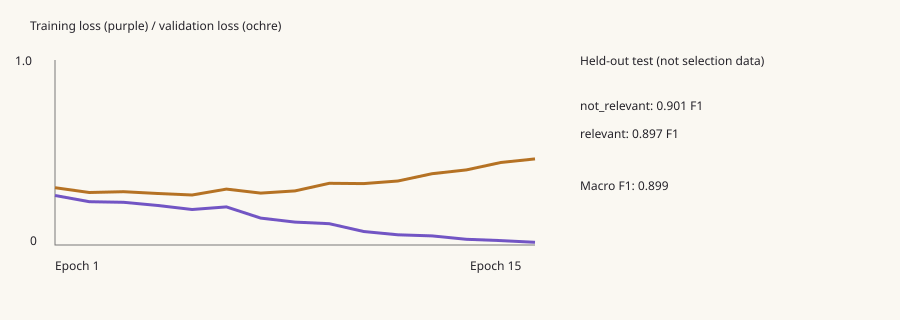

In [5]:
svg = (OUTPUT / TASK / "training.svg").read_text()
try:
    from IPython.display import SVG, display
    display(SVG(svg))
except ImportError:
    print("Graph saved at", OUTPUT / TASK / "training.svg")
print("Labels:", metadata["labels"])
print("Confusion matrix:", metadata["test"]["confusion_matrix"])
print("Test macro F1:", metadata["test"]["macro_f1"])
print("Baseline macro F1:", metadata["baseline_test"]["macro_f1"])
print(metadata["limitations"])


## Verify inference and export to Aletheia

The export uses `.npz` numeric arrays with pickle disabled, a versioned feature contract, and checksums. It is the same inference code as the backend. The project shows both models in **Experimental model analysis**; their outputs do not override citations or decide factual sufficiency.

Extract the archive at the project's `backend/` directory, so files land in `models/research/<task>/`. Keep `RESEARCH_MODELS_ENABLED=true` and `RESEARCH_MODELS_DIR=models/research`. Restart the API after replacing artifacts because loaded models are cached. Do not promote a model based on training loss alone.


In [6]:
from app.services.research_models import PairClassifier, pair_features
import numpy as np
classifier = PairClassifier.load(OUTPUT / TASK)
example = next(json.loads(line) for line in (DATA / f"{TASK}.jsonl").read_text().splitlines() if json.loads(line)["split"] == "test")
scores = classifier.predict(pair_features([(example["query"], example["passage"])]))[0]
assert np.isfinite(scores).all() and np.isclose(scores.sum(), 1)
print("Example:", example["query"])
print("Actual label:", metadata["labels"][example["label"]])
print("Predicted scores:", dict(zip(metadata["labels"], map(float, scores))))
import zipfile
archive = ROOT / f"aletheia-{TASK}-model.zip"
with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as bundle:
    for path in (OUTPUT / TASK).iterdir():
        bundle.write(path, path.relative_to(ROOT))
    bundle.write(DATA / "sources.json", "datasets/research/sources.json")
print("Export:", archive)
try:
    from google.colab import files
    files.download(str(archive))
except ImportError:
    pass


Example: The shape of the path of an object undergoing projectile motion in two dimensions is a what?
Actual label: relevant
Predicted scores: {'not_relevant': 8.609942597104236e-06, 'relevant': 0.9999914169311523}
Export: /private/var/folders/w3/d0mk82h956lg9mz28lwzzrmc0000gn/T/aletheia-notebook-qxv94yd8/aletheia-colab/backend/aletheia-relevance-model.zip
